# dat_col_plotting from pkl
1. get "df_77_97_mrn" from pkl
2. plot_Multiple cols on same axis [ ie col & filtered col]
3. Plot_multi_cols_dual [Individual scalling -- all axis on tr side]
4. Create "plt_lst" = list of columns you want to include in the analysis and plotting
5. Read col names from df_77_97_mrn column names and paste to a list.

# Import Libraries and run defs

In [35]:
# Imports required for Loading, sorting .csx files to create specific data sets ie mrn inbody readings. 
%run ./sys_funcs.py              # loads all the def functions in sys_funcs.py into memory
#import sys_funcs                 # gives access to these def function digitalform that are in memory
from pathlib import Path
import csv
import pandas as pd
import numpy as np
#import tkinter as tk
import pickle
from pathlib import Path
import csv
import os
import sys
from datetime import datetime
from datetime import time
from sys_funcs import read_csv_to_array
from sys_funcs import clean_wsl_path
from sys_funcs import array_to_dt_row_dict
from sys_funcs import make_blnk_update_row_dict
from sys_funcs import transpose_csv_to_col_dict
#from sys_funcs import update_values_with_config, get_update_result
from sys_funcs import transfer_updates
from sys_funcs import get_dtv_range
from sys_funcs import universal_import
from sys_funcs import parse_inbody_timestamp
from sys_funcs import build_lut
from sys_funcs import extract_a_column_as_df
from sys_funcs import extract_multicolumns_as_df
from sys_funcs import validate_and_sort_timestamps
from sys_funcs import extract_and_filter_by_time_window
from sys_funcs import read_file_dual_path
from sys_funcs import write_file_dual_path
from sys_funcs import asc_to_csv_cnv
from collections.abc import Mapping
import re
#from sys_funcs import 

In [36]:
def scale_mean_to_one(series):
    """Scale a Pandas Series so that its mean becomes 1."""
    mean_val = series.mean()
    return series / mean_val

In [37]:
def write_df_to_pickle(df, filename):
    """
    Writes a DataFrame to a pickle file.

    Parameters
    ----------
    df : pd.DataFrame
        The dataframe to save.
    filename : str
        The pickle filename, e.g. 'mydata.pkl'.
    """
    df.to_pickle(filename)

# usage 
# write_df_to_pickle(df, "df.pkl")


In [67]:
def plot_multi_dual(df, *cols, save_pdf=True):
    # this uses a "df" and a "plotlist" and plots the graphs on screen, and optionally plots them into a PDF file for printing
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    import pandas as pd
    import os, re

    # Work on a safe copy
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    # Color cycle (extend if needed)
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    fig, ax = plt.subplots(figsize=(12, 5))

    # First column on left axis
    ax.plot(
        df["timestamp"],
        df[cols[0]],
        marker="o",
        color=color_cycle[0],
        label=cols[0]
    )
    ax.set_ylabel(cols[0], color=color_cycle[0])
    ax.tick_params(axis="y", labelcolor=color_cycle[0])
    axes = [ax]

    # Additional columns on stacked right axes
    for i, col in enumerate(cols[1:], start=1):
        ax_new = ax.twinx()
        ax_new.spines.right.set_position(("axes", 1 + 0.1 * (i - 1)))

        color = color_cycle[i % len(color_cycle)]
        ax_new.plot(
            df["timestamp"],
            df[col],
            marker="o",
            color=color,
            label=col
        )
        ax_new.set_ylabel(col, color=color)
        ax_new.tick_params(axis="y", labelcolor=color)

        axes.append(ax_new)

    # Minor ticks every day
    ax.xaxis.set_minor_locator(mdates.DayLocator())

    # Major ticks weekly (Mondays)
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

    # Rotate major tick labels for readability
    for label in ax.get_xticklabels(which="major"):
        label.set_rotation(45)
        label.set_ha("right")

    # Grid on major ticks
    ax.grid(which="major", linestyle="--", linewidth=0.7, alpha=0.7)

    plt.xticks(rotation=45)
    plt.title(" / ".join(cols) + " over time")
    plt.tight_layout()

    # === SAVE BLOCK (PDF, WSL-safe, sanitized filename) ===
    if save_pdf:
        save_dir = "/mnt/c/Users/bhuns/OneDrive/___ib_plots"
        os.makedirs(save_dir, exist_ok=True)

        # Build clean filename
        chart_title = " vs ".join(cols)
        chart_title = chart_title.replace("/", "_")
        chart_title = re.sub(r'[^A-Za-z0-9_-]+', '_', chart_title)

        # Add timestamp
        from datetime import datetime
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        chart_title = f"{timestamp}_{chart_title}"

        pdf_path = f"{save_dir}/{chart_title}.pdf"

        fig.savefig(pdf_path, dpi=300, bbox_inches="tight")

    plt.show()

In [38]:

def original that works plot_multi_dual(df, *cols):
    # this uses a "df" and a "plotlist" and plots the graphs on screen, and optionally plots them into a PDF file for printing
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    import pandas as pd
    import os, re

    # Work on a safe copy
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    # Color cycle (extend if needed)
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    fig, ax = plt.subplots(figsize=(12, 5))

    # First column on left axis
    ax.plot(
        df["timestamp"],
        df[cols[0]],
        marker="o",
        color=color_cycle[0],
        label=cols[0]
    )
    ax.set_ylabel(cols[0], color=color_cycle[0])
    ax.tick_params(axis="y", labelcolor=color_cycle[0])
    axes = [ax]

    # Additional columns on stacked right axes
    for i, col in enumerate(cols[1:], start=1):
        ax_new = ax.twinx()
        ax_new.spines.right.set_position(("axes", 1 + 0.1 * (i - 1)))

        color = color_cycle[i % len(color_cycle)]
        ax_new.plot(
            df["timestamp"],
            df[col],
            marker="o",
            color=color,
            label=col
        )
        ax_new.set_ylabel(col, color=color)
        ax_new.tick_params(axis="y", labelcolor=color)

        axes.append(ax_new)

    # Minor ticks every day
    ax.xaxis.set_minor_locator(mdates.DayLocator())

    # Major ticks weekly (Mondays)
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

    # Rotate major tick labels for readability
    for label in ax.get_xticklabels(which="major"):
        label.set_rotation(45)
        label.set_ha("right")

    # Grid on major ticks
    ax.grid(which="major", linestyle="--", linewidth=0.7, alpha=0.7)

    plt.xticks(rotation=45)
    plt.title(" / ".join(cols) + " over time")
    plt.tight_layout()

    # === SAVE BLOCK (PDF, WSL-safe, sanitized filename) ===
    save_dir = "/mnt/c/Users/bhuns/OneDrive/___ib_plots"
    os.makedirs(save_dir, exist_ok=True)

    # Build clean filename
    chart_title = " vs ".join(cols)
    chart_title = chart_title.replace("/", "_")
    chart_title = re.sub(r'[^A-Za-z0-9_\-]+', '_', chart_title)
#=========================================================================
 # Add timestamp
    from datetime import datetime
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    chart_title = f"{timestamp}_{chart_title}"
    
    pdf_path = f"{save_dir}/{chart_title}.pdf"
    
    fig.savefig(pdf_path, dpi=300, bbox_inches="tight")   

#======================================================================
    pdf_path = f"{save_dir}/{chart_title}.pdf"

#   fig.savefig(pdf_path, dpi=300, bbox_inches="tight")

    plt.show()


# Reading updated data from Pickle [df_77_97_mrn]

In [39]:
import pickle
with open("df_77_97_mrn.pkl", "rb") as f:  
    df_77_97_mrn = pickle.load(f)

In [40]:
# verify df_77_97_mrn

# start Building series of plots ===================================================================================

# Creating a plot of value using **"df_77_97_mrn"**

## List of available data columns in **"df_77_97_mrn"**

In [73]:
# verify df_77_97_mrn.columns.tolist


In [42]:
# verify for col in df_77_97_mrn.columns:     print(col)


## Build & run the plots

In [43]:
# verify df_77_97_mrn

In [62]:
# Plots by subject weighth distribution TO ADD GO TO "Combining77_97"|Dat_Lst =" AND ADD THE DESIRED COL_NAME TO THE  PRIORITY DAT LIST THEN RERUN AND ADD TO THE "for col in df_77_97_mrn.columns:" IN THIS WORKBOOK]
# plt_lst = ["ecw/tbw","smm_(skeletal_muscle_mass),vfa_(visceral_fat_area)"]
plt_lst = ["ecw/tbw","smm_(skeletal_muscle_mass)"]
# plot_multi_dual(df_77_97_mrn, *plt_lst , save_pdf=True)                   # ["ecw/tbw","smm_(skeletal_muscle_mass)"
# To save the plot as a PDF (default)
plot_multi_dual(df, 'col1', 'col2', save_pdf=True)

# To just display the plot without saving a PDF
plot_multi_dual(df, 'col1', 'col2', save_pdf=False)



# To save the plot as a PDF (default)
plot_multi_dual(df, 'col1', 'col2', save_pdf=True)

# To just display the plot without saving a PDF
plot_multi_dual(df, 'col1', 'col2', save_pdf=False)


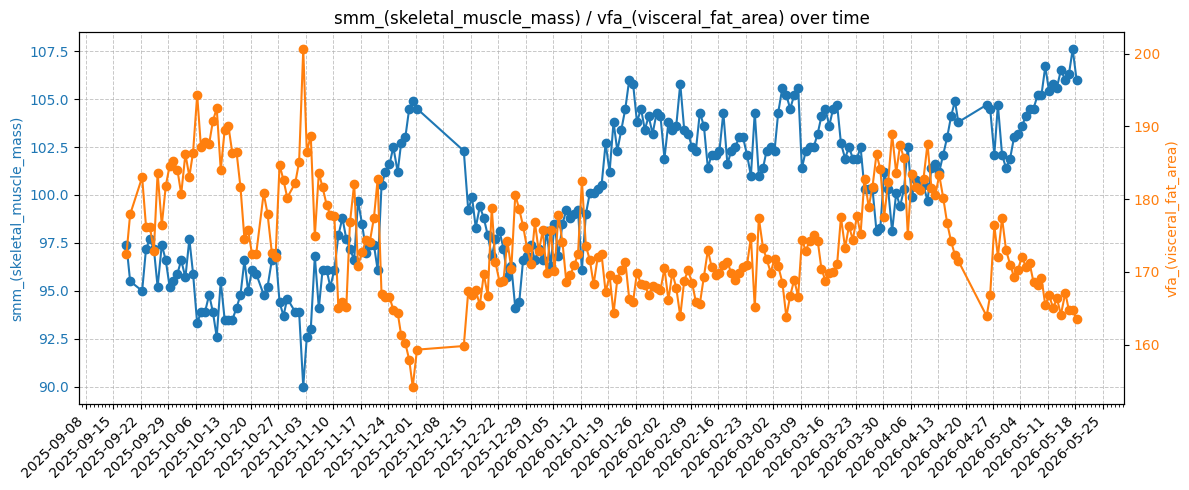

In [81]:
# Plots by subject  
plt_lst = ["smm_(skeletal_muscle_mass)","vfa_(visceral_fat_area)"]
plot_multi_dual(df_77_97_mrn, *plt_lst,save_pdf=False) 
# plot_multi_dual(df_77_97_mrn, *plt_lst,save_pdf=True)  

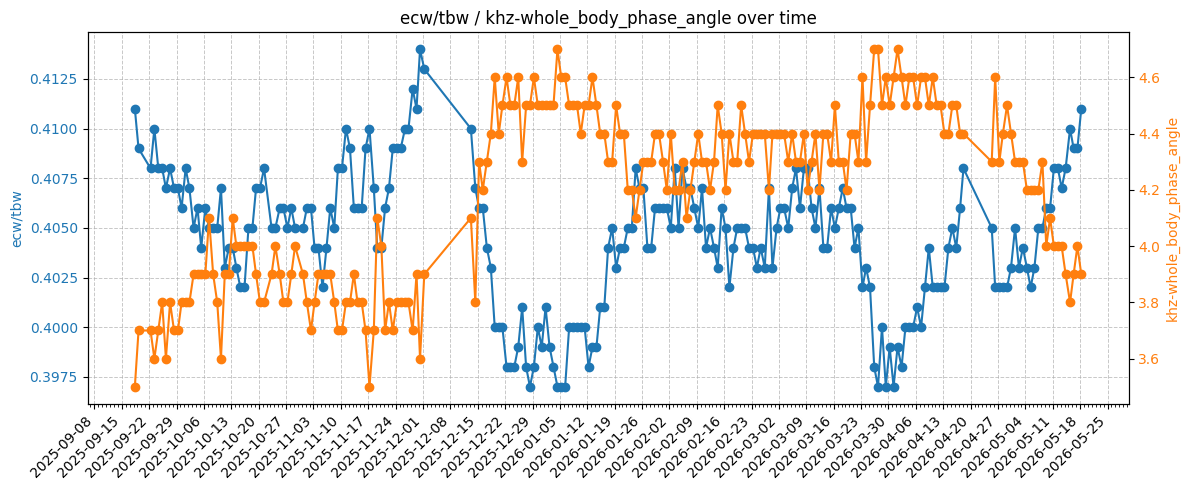

In [82]:
# Plots by subject
plt_lst = ["ecw/tbw",'khz-whole_body_phase_angle']
plot_multi_dual(df_77_97_mrn, *plt_lst,save_pdf=False) 
# plot_multi_dual(df_77_97_mrn, *plt_lst,save_pdf=True)  

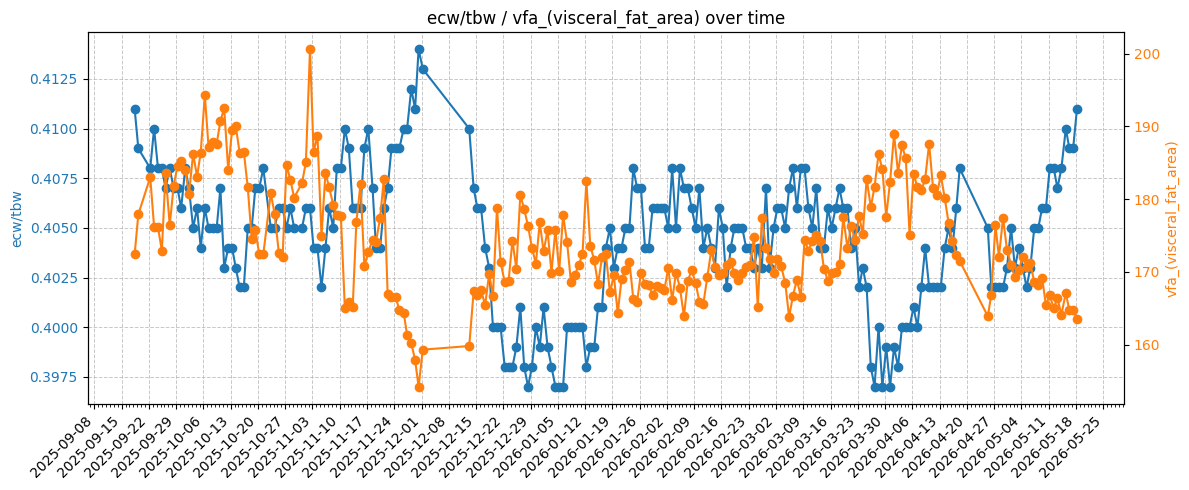

In [83]:
# Plots by subject
plt_lst = ["ecw/tbw","vfa_(visceral_fat_area)"]
plot_multi_dual(df_77_97_mrn, *plt_lst,save_pdf=False) 
#plot_multi_dual(df_77_97_mrn, *plt_lst,save_pdf=True)  

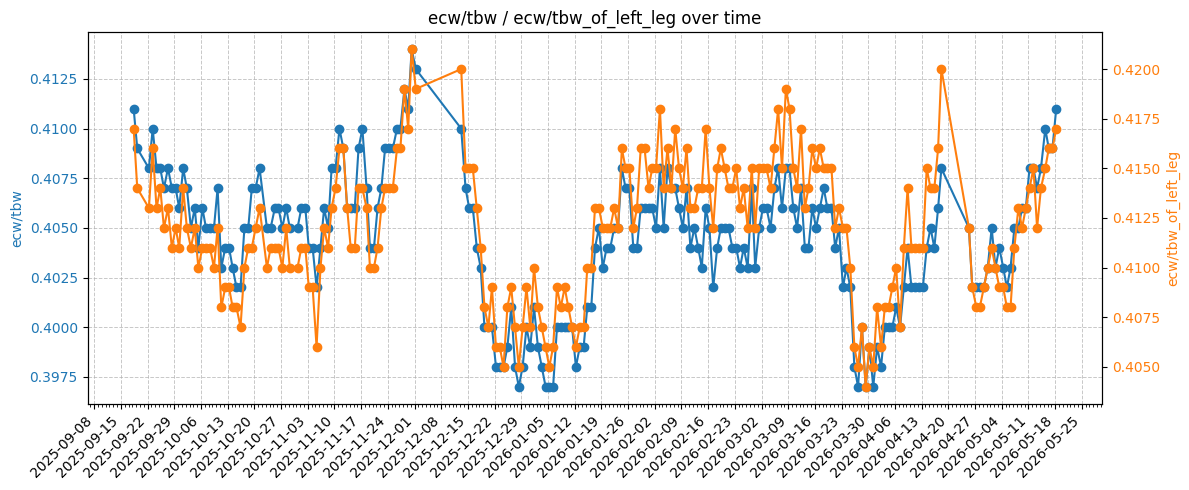

In [84]:
# Plots by subject
plt_lst = ["ecw/tbw","ecw/tbw_of_left_leg"]
plot_multi_dual(df_77_97_mrn, *plt_lst,save_pdf=False) 
#plot_multi_dual(df_77_97_mrn, *plt_lst,save_pdf=True)  

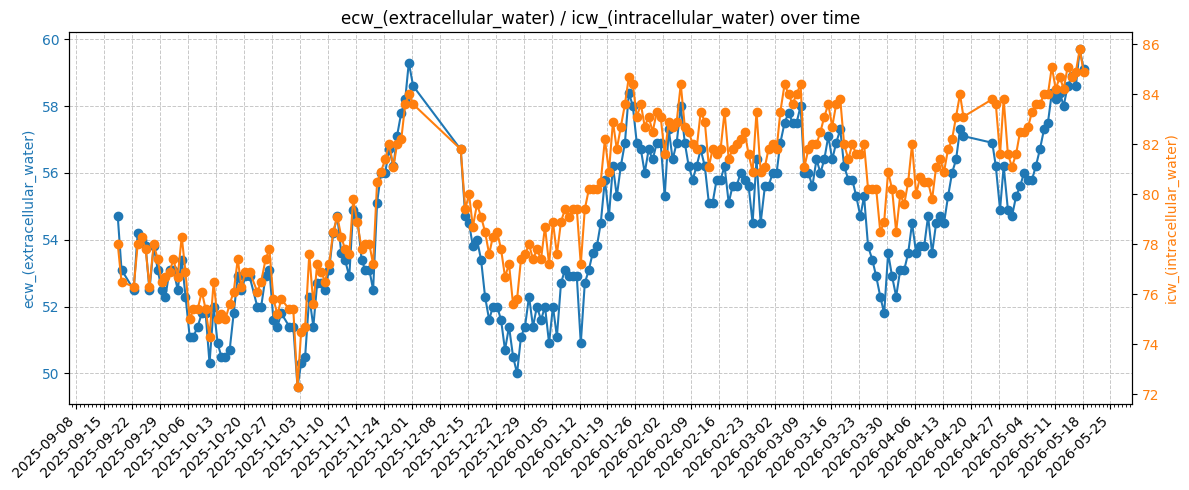

In [85]:
# Plots by subject
plt_lst = ["ecw_(extracellular_water)","icw_(intracellular_water)"]
plot_multi_dual(df_77_97_mrn, *plt_lst,save_pdf=False) 
#plot_multi_dual(df_77_97_mrn, *plt_lst,save_pdf=True)  

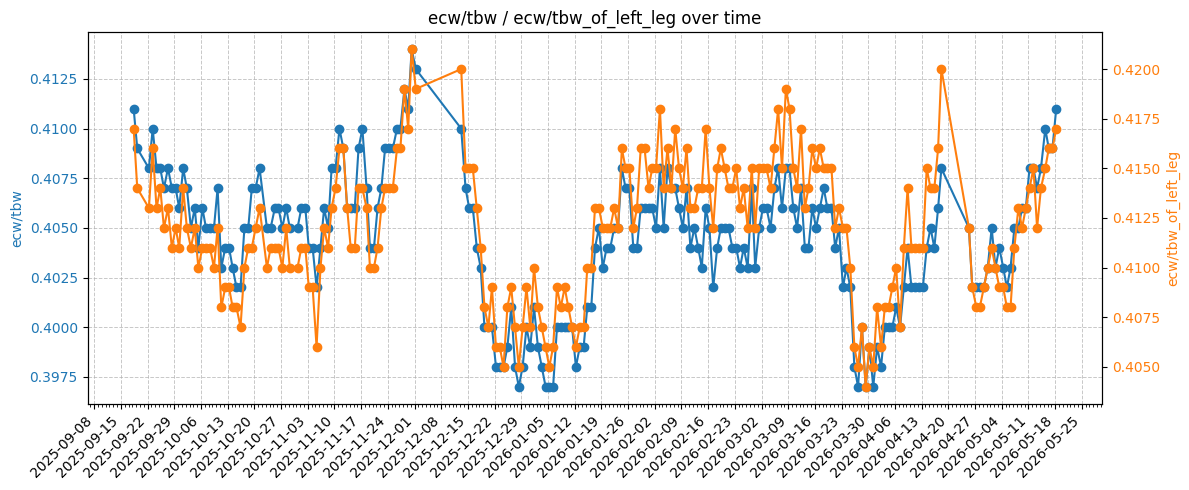

In [86]:
# Plots by subject
plt_lst = ["ecw/tbw","ecw/tbw_of_left_leg"]
plot_multi_dual(df_77_97_mrn, *plt_lst,save_pdf=False) 
#plot_multi_dual(df_77_97_mrn, *plt_lst,save_pdf=True)  

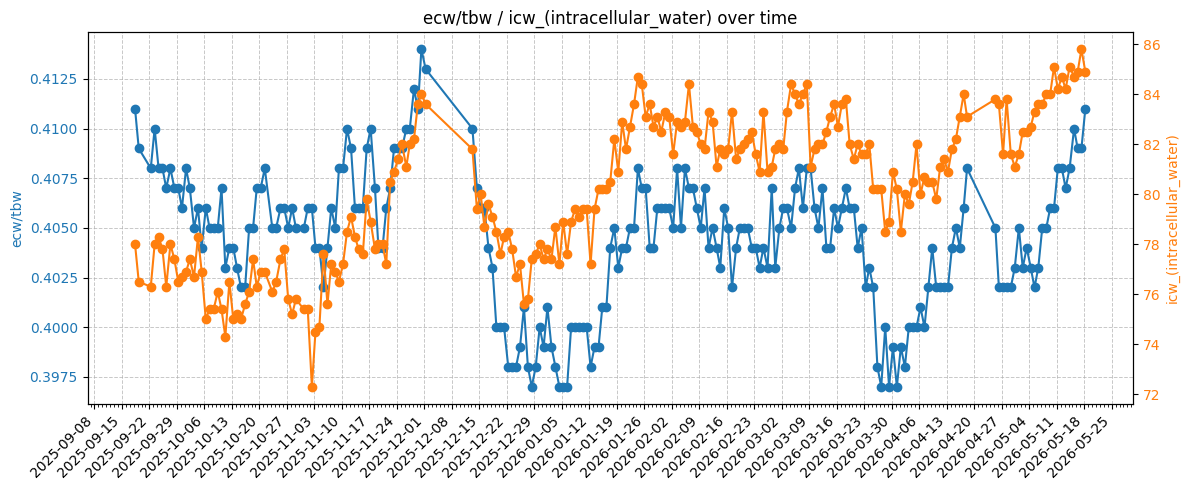

In [87]:
# Plots by subject
plt_lst = plt_lst = ["ecw/tbw",'icw_(intracellular_water)']
plot_multi_dual(df_77_97_mrn, *plt_lst,save_pdf=False) 
#plot_multi_dual(df_77_97_mrn, *plt_lst,save_pdf=True)  

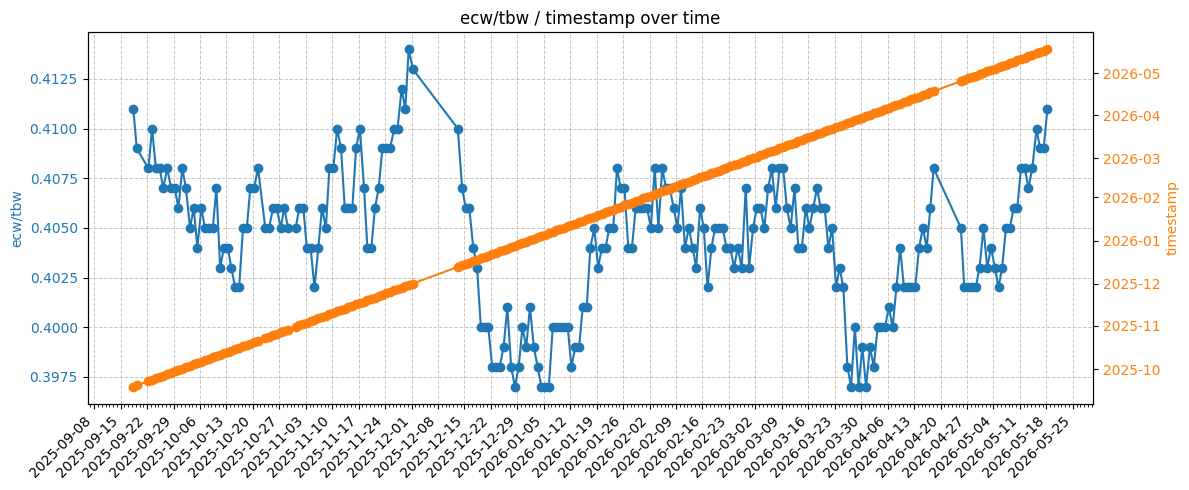

In [88]:
# Plots by subject
plt_lst = plt_lst = ["ecw/tbw",'timestamp']
plot_multi_dual(df_77_97_mrn, *plt_lst,save_pdf=False) 
#plot_multi_dual(df_77_97_mrn, *plt_lst,save_pdf=True)  